<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> Dimensionality_Reduction_PCA_LDA_on_preloaded_data </h2>
</div>


# Module 8 Case Study 1: Dimenstionality Reduction

    Case Study
        Objective:
                •Understand and practice principal component analysis using scikit learn.

## 1.Scikit learn comes with pre-loaded dataset, load the digits dataset from that collection 
        and write a helper function to plot the image using matplotlib.
        [Hint:Explore datasets module from scikit learn]

## 1. Import Library

In [40]:
from sklearn.datasets import load_digits
import pandas as pd

In [41]:
#read digits dataset from sklearn "load_digits" dataset
digits = load_digits()

#print data shape:  (1797, 64)  means 1797 row, 64 col
print(digits.data.shape)

(1797, 64)


## 2. Data Wrangling

In [42]:
#sample data, its an array of digits, converts this to Dataframe below
digits.data
# This is input data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [43]:
digits.target
# This is output data

array([0, 1, 2, ..., 8, 9, 8])

In [44]:
#Read data which is array and convert it to DF
#digits.data will give I/P data in it
X = pd.DataFrame(digits.data)
X.head()
##df.max().max()  #max digit is 16

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [45]:
#digits.target will give O/P data in it
Y = pd.DataFrame(digits.target)
Y.head()

,0
0,0
1,1
2,2
3,3
4,4


## 3. Data Visualization

>    Write a helper function to plot the image using matplotlib.
        [Hint:Explore datasets module from scikit learn]

4


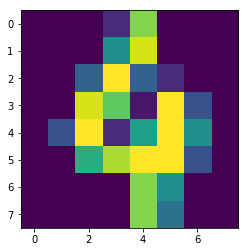

In [46]:
import matplotlib.pyplot as plt 
%matplotlib inline

def plot_digit(x,index):
    plt.imshow(x.reshape(8,8))
    print(index)
    
plot_digit(digits.data[100],digits.target[100])

## 4. Apply ML Without PCA


> Make a train -test split with 20% of the data set aside for testing. 
   > Fit a logistic regression model and observe the accuracy
    
    #Prabha: Not sure why logistic regression, here data is not binary or 2 value. o/p is from value 0 to 16

In [47]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,Y,test_size=.20, random_state=1)
train_y.head()

,0
1328,4
1562,9
750,6
1788,4
408,2


In [48]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_x, train_y)
pred_y = lr.predict(test_x)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


### 4.1 Without PCA ACCURACY

In [49]:
from sklearn import metrics
metrics.accuracy_score(test_y,pred_y)

#Here accuracy is 96%

0.9694444444444444

## 5. Apply PCA on Data

#### 3.  Using scikit learn perform a PCA transformation such that the transformed dataset can explain 95% of the variance in the original dataset. 
    Find out the number of components in the projected subspace.
    [Hint:Refer to decomposition module of scikit learn]

In [50]:
#tRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
print(X_train.shape)


(1437, 64)


In [51]:
#Apply PCA on test train split Data

from sklearn.decomposition import PCA


sklearn_pca = PCA(n_components=0.95)
sklearn_pca.fit(X_train)

print(train_x.shape)
#PCA on X_Train
X_train_transformed = sklearn_pca.transform(X_train)

print(X_train_transformed.shape)
print(X_test.shape)

#PCA on X_Test
X_test_transformed =sklearn_pca.transform(X_test)
print(X_test_transformed.shape)

## Here it kept same rows in both test and train data, no of column got reduced

(1437, 64)
(1437, 28)
(360, 64)
(360, 28)


In [52]:
# variance it provides varience in% 
## Here no of components are niot 2, its more than 10
a = sklearn_pca.explained_variance_ratio_
a

array([0.1470014 , 0.13534673, 0.11758021, 0.08636642, 0.05870678,
       0.04933217, 0.04264567, 0.03647665, 0.03409222, 0.03067407,
       0.02375649, 0.02227613, 0.01832178, 0.01801441, 0.01504018,
       0.01388698, 0.01316089, 0.01242737, 0.01019944, 0.00942293,
       0.00893532, 0.00808029, 0.00766545, 0.00705878, 0.00705399,
       0.00591078, 0.00565872, 0.00508592])

In [53]:
a.sum()

0.9501781798298709

* Total 29 components in the projected subspace

## 5.1 Apply ML On PCA Data

#### 4.Transform the dataset and fit a logistic regression and observe the accuracy. 
    Compare it with the previous model andcomment on the accuracy.
    [Hint: Project both the train and test samples to the new subspace]

In [54]:
#Apply LR After PCA
lr = LogisticRegression(penalty='l1')
lr.fit(X_train_transformed,y_train)
y_predict = lr.predict(X_test_transformed)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


### 5.2 With PCA ACCURACY

In [55]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_predict,y_test)
print(accuracy)

0.9805555555555555


## 6 Conclusion

### After PCA, LR Accuracy is more, which is 98%, before it was 96 %
* Logistic Regression directly had 96% Accuracy, PCA has 98%.
* Here we applied PCA on splitted data and got accuracy 98. If we apply PCA directly on Complete data and then split, accuracy will comes down to 95

## 7.  MORE ANALYSIS
> Compute the confusion matrix and count the number of instances that has gone wrong. 
    For each of the wrong sample,plot the digit along with predicted and original label.
    #Prabha Half done


In [56]:

from sklearn.metrics import confusion_matrix
print (confusion_matrix(y_predict,y_test))

[[43  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  0  0]
 [ 0  0 36  0  0  0  0  0  0  0]
 [ 0  0  0 40  0  0  0  0  0  0]
 [ 0  0  0  0 38  0  0  0  0  0]
 [ 0  0  0  1  0 30  0  1  2  1]
 [ 0  1  0  0  0  0 37  0  0  0]
 [ 0  0  0  0  0  0  0 35  0  0]
 [ 0  0  0  0  0  0  0  1 27  0]
 [ 0  0  0  0  0  0  0  0  0 33]]


In [57]:
df = pd.DataFrame(a)
df

,0
0,0.147001
1,0.135347
2,0.117580
3,0.086366
4,0.058707
5,0.049332
6,0.042646
7,0.036477
8,0.034092
9,0.030674


In [58]:

for i in df:
   # print(df[i])
    sum=0
    for j in range(9):
       # print(i,j, df[j][i])
        if i==j:
            
            continue
        else:
            sum=sum+df[j][i]
    print("Sum of instances that has gone wrong :", sum)
        

KeyError: 1

In [59]:
#Here some error we are getting, but actual edu sol will get array as below
#(array([108, 116, 126, 173, 248, 249, 267]),)

import numpy as np
np.where(y_predict != y_test)

C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: elementwise != comparison failed; this will raise an error in the future.
  """


ValueError: Wrong number of items passed 360, placement implies 1

In [60]:
#Here some error we are getting, but actual edu sol will get some plot
index=267
print(y_predict[index],y_test[index])
plot_digit(X_test[index],y_test[index])
print(lr.predict(X_test_transformed[index].reshape(1,-1)))


KeyError: 267

# LDA

In [61]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
print(X_train.shape)

(1437, 64)


In [62]:
#Apply LDA on test_x and Test_y

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

sklearn_lda = lda()

#Fit we use both x_train and y_train
sklearn_lda.fit(X_train,y_train)

#X_train LDA
X_train = sklearn_lda.transform(X_train)

print("Number of components in transformed shape {}".format(X_train.shape[1]))

#X_test LDA
X_test =sklearn_lda.transform(X_test)
print(X_test.shape)

Number of components in transformed shape 9
(360, 9)


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")


In [63]:
## Applied LR on LDA applied dataset

lr = LogisticRegression(penalty='l1')
lr.fit(X_train,y_train)
y_predict = lr.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_predict,y_test)
print(accuracy)

0.9638888888888889


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


## Conclusion:

* Logistic Regression directly had 96% Accuracy, After LDA lr  has 96.38% accuracy